### Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [24]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [25]:
df = pd.read_csv("onlinefraud.csv")
df = df.drop(columns= "isFlaggedFraud")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


## Exploratory Data Analysis (EDA)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 485.4 MB


In [27]:
df.shape

(6362620, 10)

In [28]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

- The dataset contains no missing values

In [29]:
df.duplicated().sum()

np.int64(0)

- No duplicate transactions were found in the dataset.

In [30]:
# Use smaller dtype for numberical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast= 'float')
    if df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast= 'unsigned')
        
df['type'] = df['type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            uint16  
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         uint8   
dtypes: category(1), float64(5), str(2), uint16(1), uint8(1)
memory usage: 364.1 MB


In [31]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [32]:
df.describe(include= ['str', 'category']).T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [33]:
df['nameOrig'].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

- There are 6,353,307 unique customers initiating transactions.

In [34]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

- There are 2,722,362 unique transaction recipients.

In [35]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
******************************


### Feature Engineering

In [36]:
df['hour_of_day'] = df['step'] % 24

df['is_Merchant_Dest'] = df['nameDest'].str.startswith('M').astype(int)

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df.loc[df['is_Merchant_Dest'] == 1, 'errorBalanceDest'] = 0
df = df.drop(columns= 'step')

In [37]:
# Change the order of columns
df = df[['hour_of_day', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
         'oldbalanceDest', 'newbalanceDest', 'nameOrig', 'nameDest',
         'is_Merchant_Dest', 'errorBalanceOrig', 'errorBalanceDest', 'isFraud']]
df

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1
6362616,23,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1
6362617,23,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1
6362618,23,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1


### Graphs

#### Claude

In [ ]:
#  GLOBAL STYLE SETTINGS
PALETTE_FRAUD    = "#FF4C4C"   # red  – fraudulent
PALETTE_LEGIT    = "#4CAEFF"   # blue – legitimate
PALETTE_NEUTRAL  = "#6C63FF"   # purple – single distribution
PALETTE_MERCHANT = "#00C49A"   # teal  – merchant
PALETTE_BG       = "#F8F9FC"   # near-white canvas
PALETTE_CARD     = "#FFFFFF"
PALETTE_TEXT     = "#1A1D2E"
PALETTE_GRID     = "#E2E6F0"
 
sns.set_theme(style="white", font="DejaVu Sans")
 
BASE_RC = {
    "figure.facecolor":    PALETTE_BG,
    "axes.facecolor":      PALETTE_CARD,
    "axes.edgecolor":      PALETTE_GRID,
    "axes.labelcolor":     PALETTE_TEXT,
    "axes.labelsize":      13,
    "axes.labelpad":       8,
    "axes.titlesize":      15,
    "axes.titlepad":       12,
    "axes.titleweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.color":          PALETTE_GRID,
    "grid.linewidth":      0.8,
    "grid.alpha":          0.7,
    "xtick.color":         PALETTE_TEXT,
    "ytick.color":         PALETTE_TEXT,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "figure.dpi":          150,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
    "savefig.facecolor":   PALETTE_BG,
}
plt.rcParams.update(BASE_RC)
 
FRAUD_LABELS   = {0: "Non-Fraud", 1: "Fraud"}
FRAUD_COLORS   = {0: PALETTE_LEGIT, 1: PALETTE_FRAUD}
LEGEND_HANDLES = [
    mpatches.Patch(color=PALETTE_LEGIT, label="✔ Non-Fraud"),
    mpatches.Patch(color=PALETTE_FRAUD, label="✘ Fraud"),
]

In [39]:
def add_subtitle(ax, text):
    ax.annotate(
        text,
        xy=(0.5, 1.02),
        xycoords="axes fraction",
        ha="center",
        fontsize=11,
        color= PALETTE_TEXT
    )

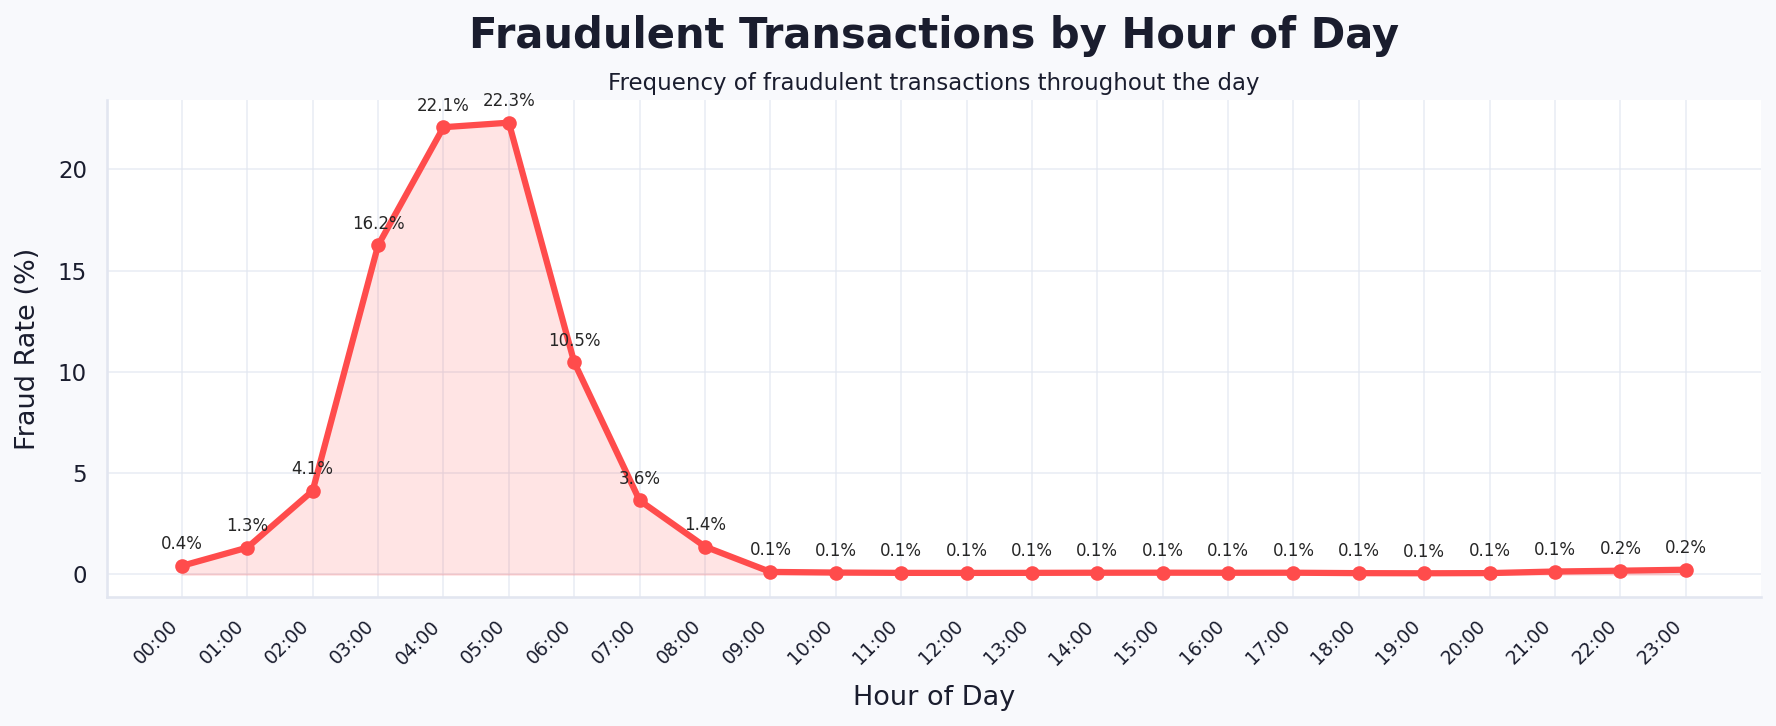

In [40]:
fraud_rate_hour = (
    df.groupby("hour_of_day")["isFraud"]
      .mean()
      * 100
)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    fraud_rate_hour.index,
    fraud_rate_hour.values,
    color=PALETTE_FRAUD,
    linewidth=3,
    marker="o"
)

ax.fill_between(
    fraud_rate_hour.index,
    fraud_rate_hour.values,
    color=PALETTE_FRAUD,
    alpha=0.15
)

ax.set_title(
    "Fraudulent Transactions by Hour of Day",
    fontsize=20,
    fontweight="bold",
    color=PALETTE_TEXT,
    pad=25
)

add_subtitle(
    ax,
    "Frequency of fraudulent transactions throughout the day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")

ax.set_xticks(range(24))
ax.set_xticklabels(
    [f"{h:02d}:00" for h in range(24)],
    rotation=45,
    ha="right",
    fontsize=9
)

for x, y in zip(
    fraud_rate_hour.index,
    fraud_rate_hour.values
):
    ax.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()

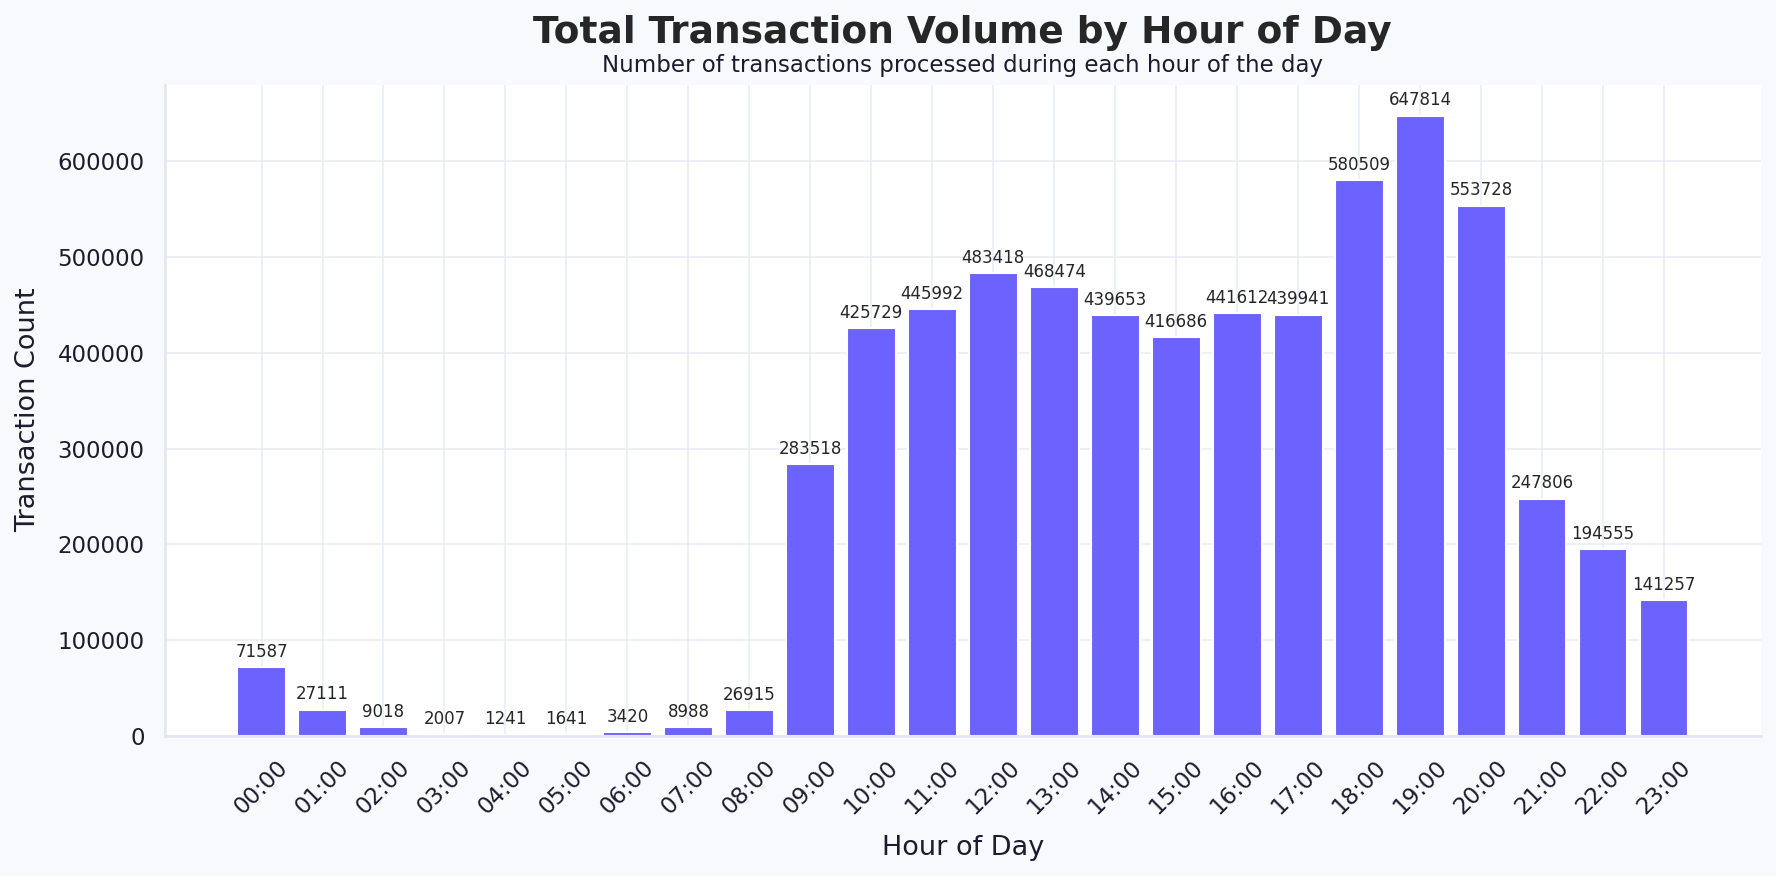

In [ ]:
# TOTAL TRANSACTION VOLUME BY HOUR
hour_counts = (
    df.groupby("hour_of_day")
      .size()
      .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=PALETTE_NEUTRAL,
    edgecolor="white",
    linewidth=1
)

ax.bar_label(
    bars,
    fmt="%.0f",
    padding=3,
    fontsize=8
)

ax.set_xticks(range(24))
ax.set_xticklabels(
    [f"{h:02d}:00" for h in range(24)],
    rotation=45
)

ax.set_title(
    "Total Transaction Volume by Hour of Day",
    fontsize=18,
    fontweight="bold",
    pad=20,
    loc="center"
)

add_subtitle(
    ax,
    "Number of transactions processed during each hour of the day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Transaction Count")

plt.tight_layout()

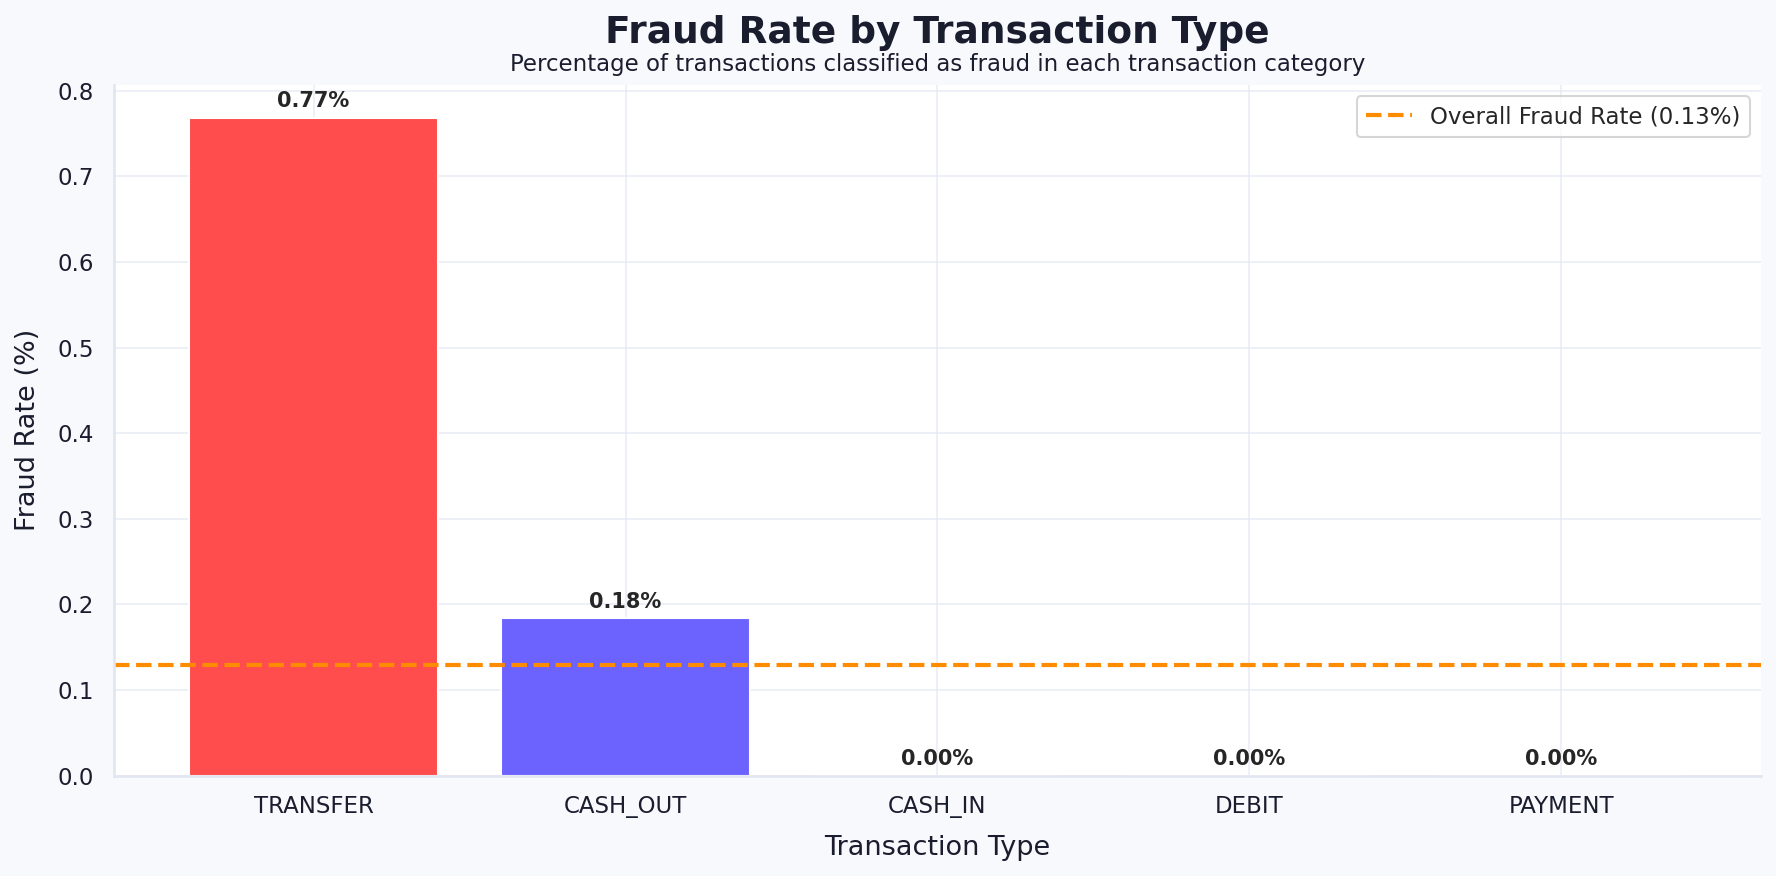

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

fraud_rate = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

bars = ax.bar(
    fraud_rate.index,
    fraud_rate.values,
    color=[
        PALETTE_FRAUD if x > fraud_rate.mean()
        else PALETTE_NEUTRAL
        for x in fraud_rate.values
    ],
    edgecolor="white",
    linewidth=1
)

ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=10,
    fontweight="bold"
)

ax.axhline(
    df["isFraud"].mean() * 100,
    color="#FF8C00",
    linestyle="--",
    linewidth=2,
    label=f"Overall Fraud Rate ({df['isFraud'].mean()*100:.2f}%)"
)

ax.set_title(
    "Fraud Rate by Transaction Type",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color= PALETTE_TEXT
)

add_subtitle(
    ax,
    "Percentage of transactions classified as fraud in each transaction category"
)

ax.set_xlabel("Transaction Type")
ax.set_ylabel("Fraud Rate (%)")

ax.legend()

plt.tight_layout()

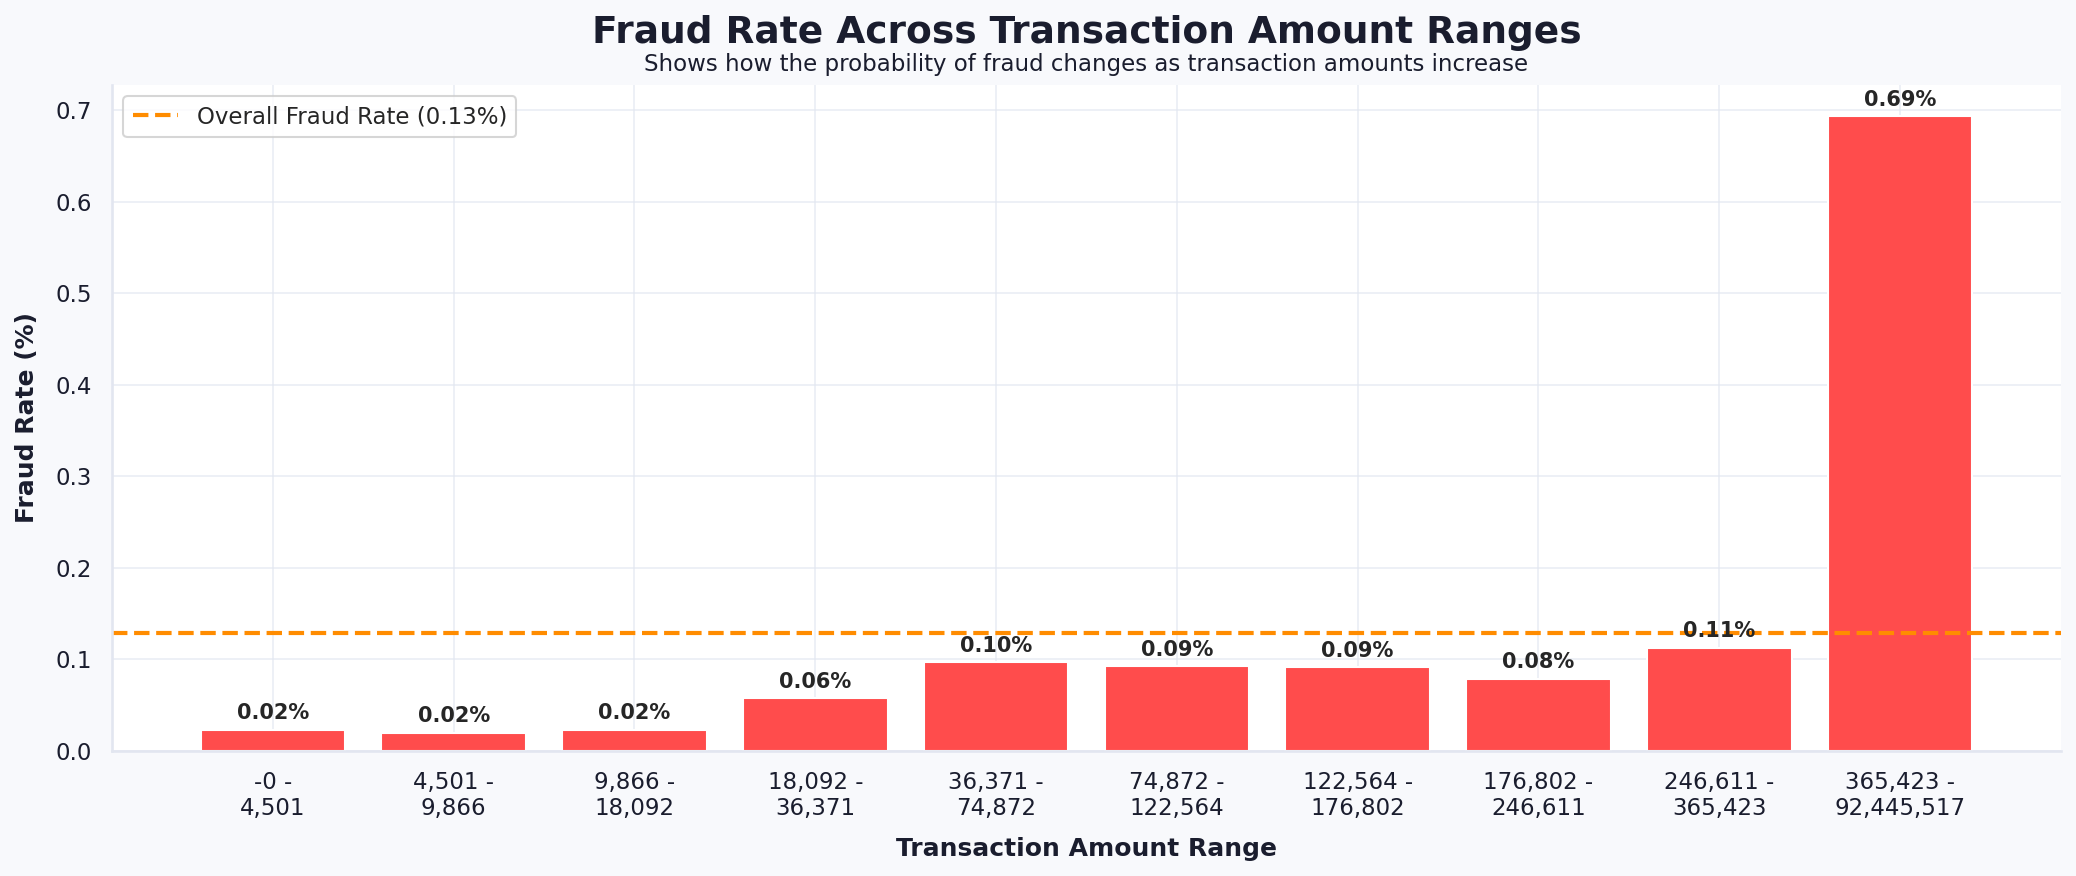

In [ ]:
# 3. AMOUNT – FRAUD RATE BY AMOUNT RANGE
# Separate amount to 10 groups equally
df["amount_bin"] = pd.qcut(
    df["amount"],
    q=10,
    duplicates="drop"
)

# Fraud rate of each group
fraud_rate_amount = (
    df.groupby("amount_bin", observed=False)["isFraud"]
      .mean()
      * 100
)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    range(len(fraud_rate_amount)),
    fraud_rate_amount.values,
    color=PALETTE_FRAUD,
    edgecolor="white",
    linewidth=1
)

# Show all values on the cols
ax.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3,
    fontsize=10,
    fontweight="bold"
)

# Average fraud rate line
overall_rate = df["isFraud"].mean() * 100

ax.axhline(
    overall_rate,
    color="#FF8C00",
    linestyle="--",
    linewidth=2,
    label=f"Overall Fraud Rate ({overall_rate:.2f}%)"
)

# Label amount range
labels = [
    f"{interval.left:,.0f} -\n{interval.right:,.0f}"
    for interval in fraud_rate_amount.index
]

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    ha="center"
)

ax.set_title(
    "Fraud Rate Across Transaction Amount Ranges",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color= PALETTE_TEXT
)

add_subtitle(
    ax,
    "Shows how the probability of fraud changes as transaction amounts increase"
)

ax.set_xlabel(
    "Transaction Amount Range",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Fraud Rate (%)",
    fontsize=12,
    fontweight="bold"
)

ax.legend()

plt.tight_layout()

df = df.drop(columns= 'amount_bin')

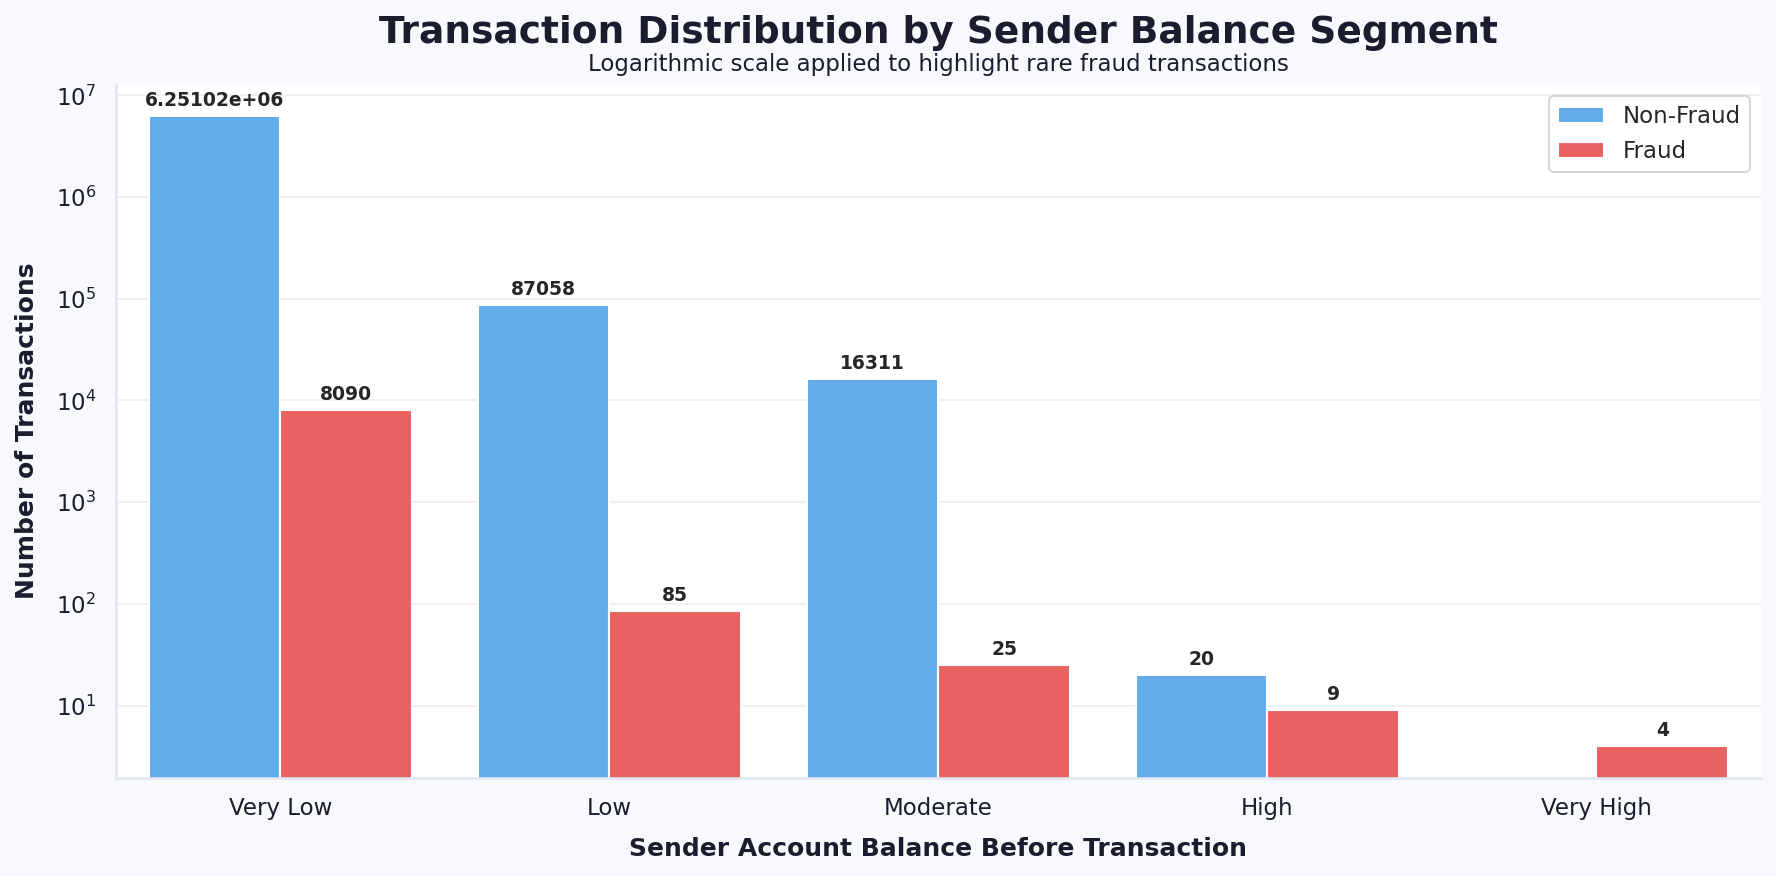

In [ ]:
# OLD BALANCE ORIG - BALANCE SEGMENTS vs FRAUD
df["oldbalanceOrg_segment"] = pd.cut(
    df["oldbalanceOrg"],
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df,
    x="oldbalanceOrg_segment",
    hue="isFraud",
    palette={
        0: PALETTE_LEGIT,
        1: PALETTE_FRAUD
    },
    ax=ax
)
ax.set_yscale("log")
# Hiển thị số trên đầu cột
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Transaction Distribution by Sender Balance Segment",
    fontsize=18,
    fontweight="bold",
    pad=20,
    loc="center",
    color= PALETTE_TEXT
)

add_subtitle(
    ax,
    "Logarithmic scale applied to highlight rare fraud transactions"
)

ax.set_xlabel(
    "Sender Account Balance Before Transaction",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Transactions",
    fontsize=12,
    fontweight="bold"
)

ax.legend(
    labels=["Non-Fraud", "Fraud"]
)

plt.tight_layout()

df = df.drop(columns= 'oldbalanceOrg_segment')

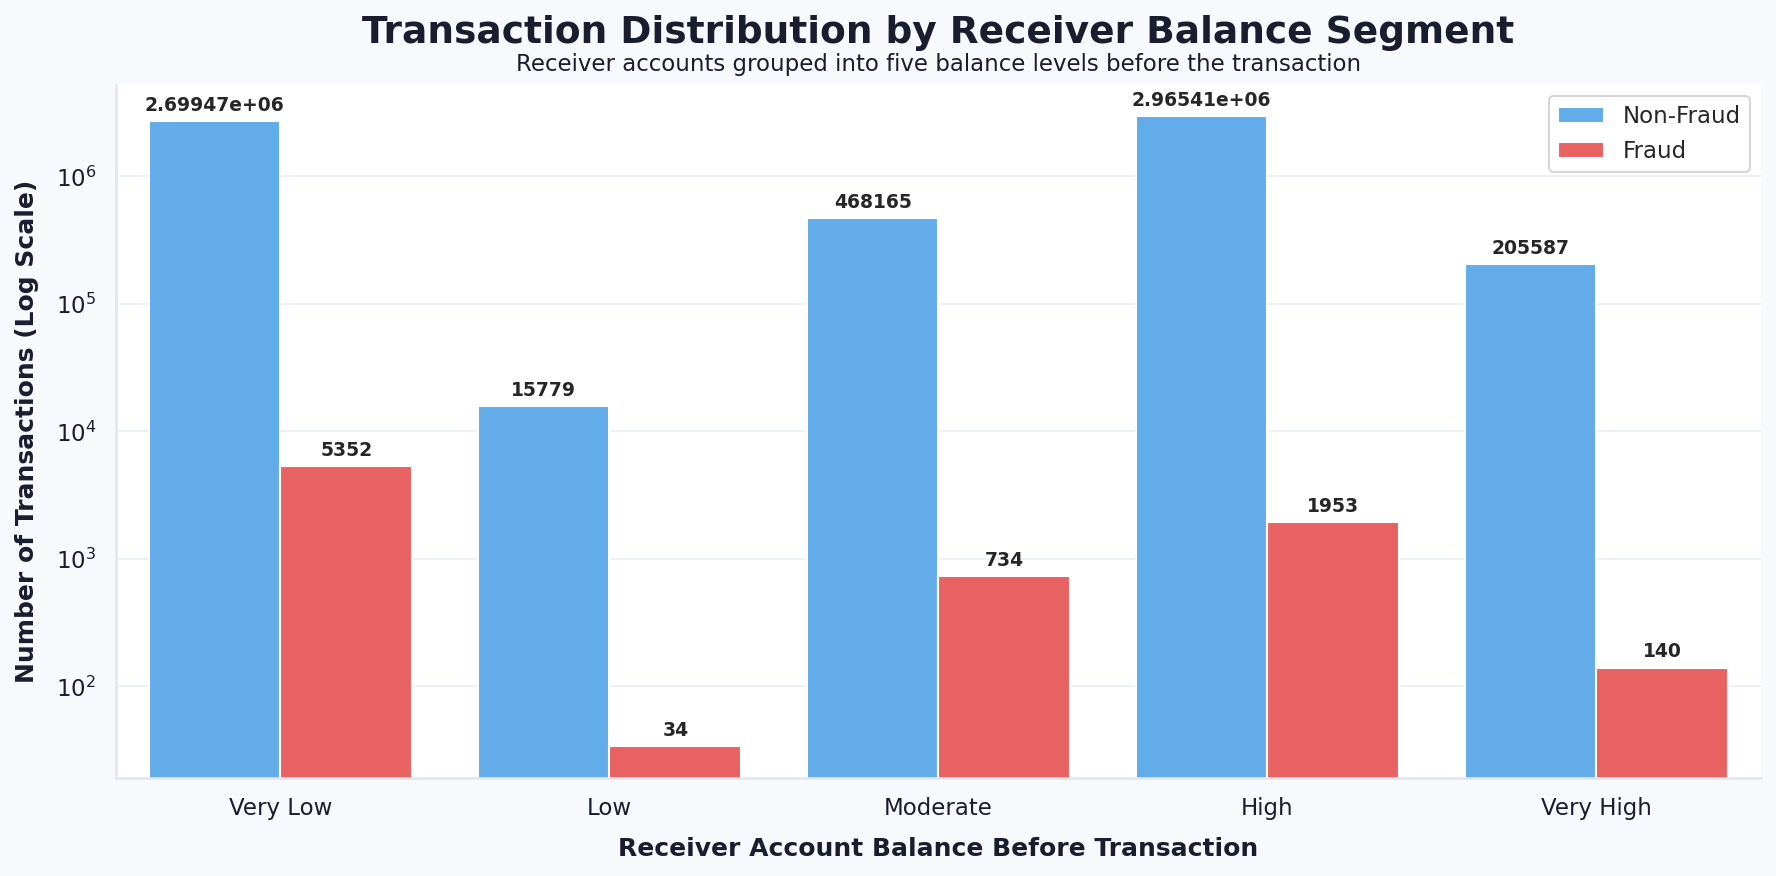

In [45]:
# ══════════════════════════════════════════════════════
# OLD BALANCE DEST - BALANCE SEGMENTS
# ══════════════════════════════════════════════════════

df["oldbalanceDest_segment"] = pd.cut(
    np.log1p(df["oldbalanceDest"]),
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df,
    x="oldbalanceDest_segment",
    hue="isFraud",
    palette={
        0: PALETTE_LEGIT,
        1: PALETTE_FRAUD
    },
    ax=ax
)

# hiện số trên đầu cột
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

# nếu fraud quá nhỏ
ax.set_yscale("log")

ax.set_title(
    "Transaction Distribution by Receiver Balance Segment",
    fontsize=18,
    fontweight="bold",
    pad=20,
    loc="center",
    color= PALETTE_TEXT
)

add_subtitle(
    ax,
    "Receiver accounts grouped into five balance levels before the transaction"
)

ax.set_xlabel(
    "Receiver Account Balance Before Transaction",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Transactions (Log Scale)",
    fontsize=12,
    fontweight="bold"
)

ax.legend(
    labels=["Non-Fraud", "Fraud"]
)

plt.tight_layout()

df = df.drop(columns= 'oldbalanceDest_segment')

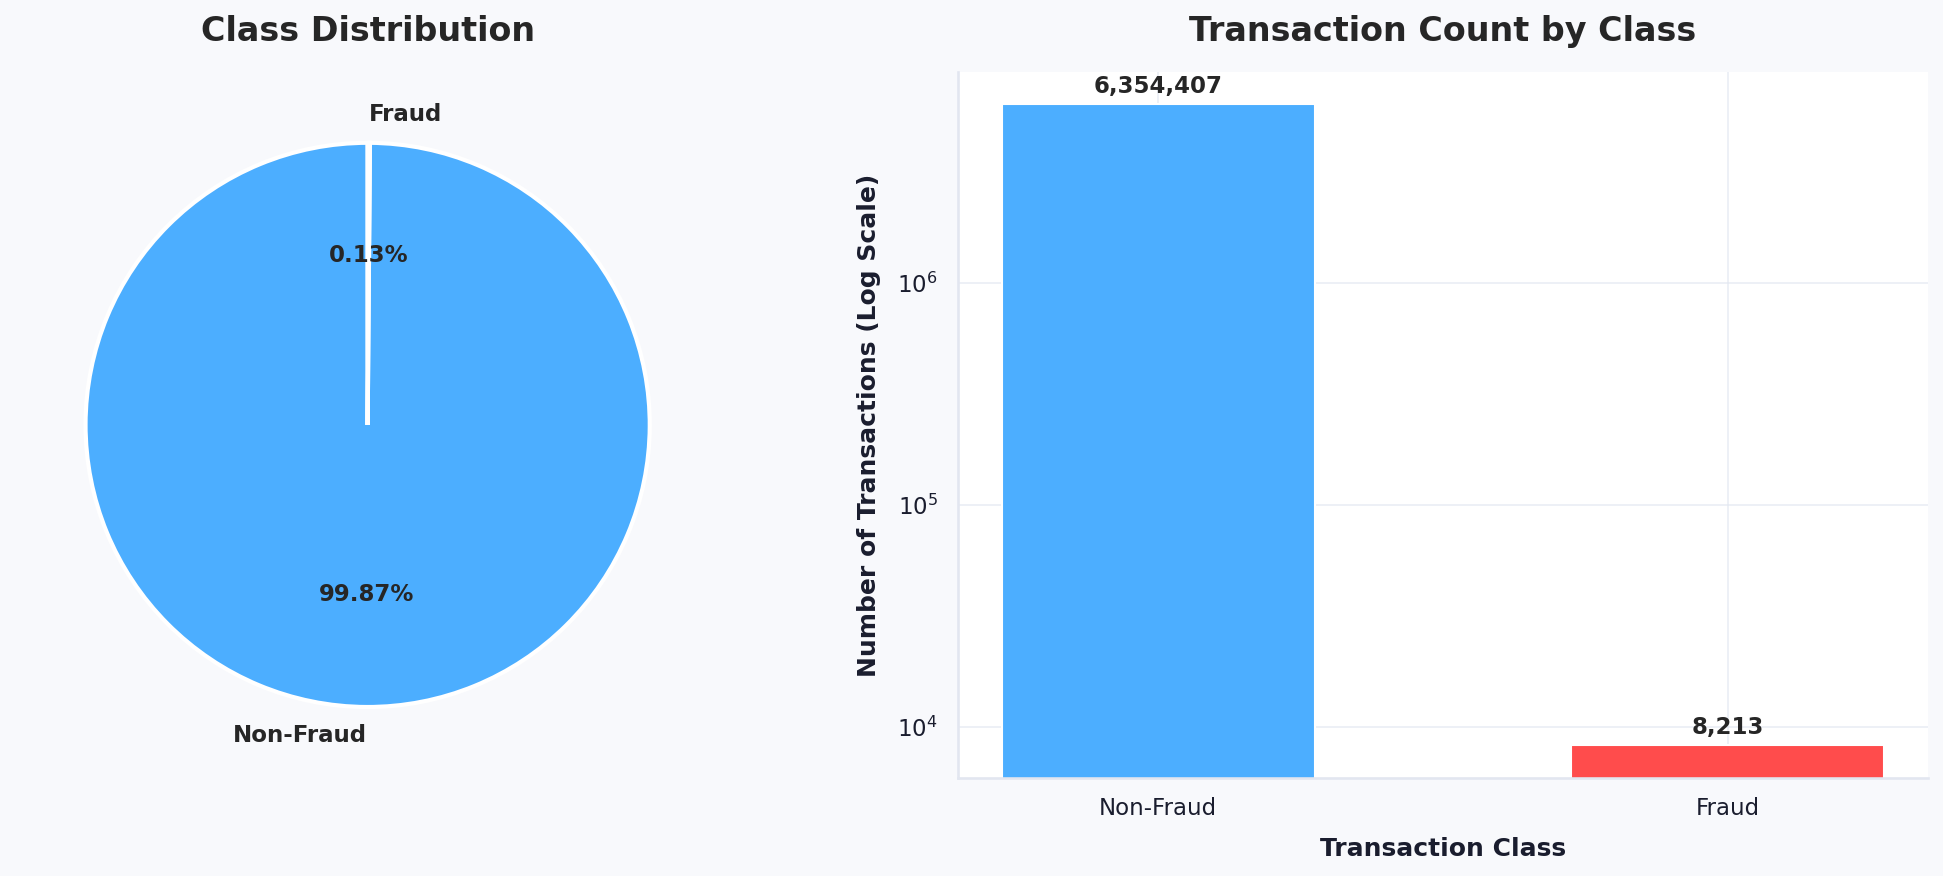

In [ ]:
# TARGET DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = df["isFraud"].value_counts().sort_index()

labels = ["Non-Fraud", "Fraud"]

colors = [
    PALETTE_LEGIT,
    PALETTE_FRAUD
]

# Left: Pie Chart
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

axes[0].set_title(
    "Class Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Right: Count Chart
bars = axes[1].bar(
    labels,
    counts.values,
    color=colors,
    edgecolor="white",
    width=0.55
)

axes[1].bar_label(
    bars,
    labels=[f"{x:,.0f}" for x in counts.values],
    padding=3,
    fontsize=11,
    fontweight="bold"
)

# Log scale để nhìn thấy Fraud
axes[1].set_yscale("log")

axes[1].set_title(
    "Transaction Count by Class",
    fontsize=16,
    fontweight="bold",
    pad=15
)


axes[1].set_xlabel(
    "Transaction Class",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Number of Transactions (Log Scale)",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

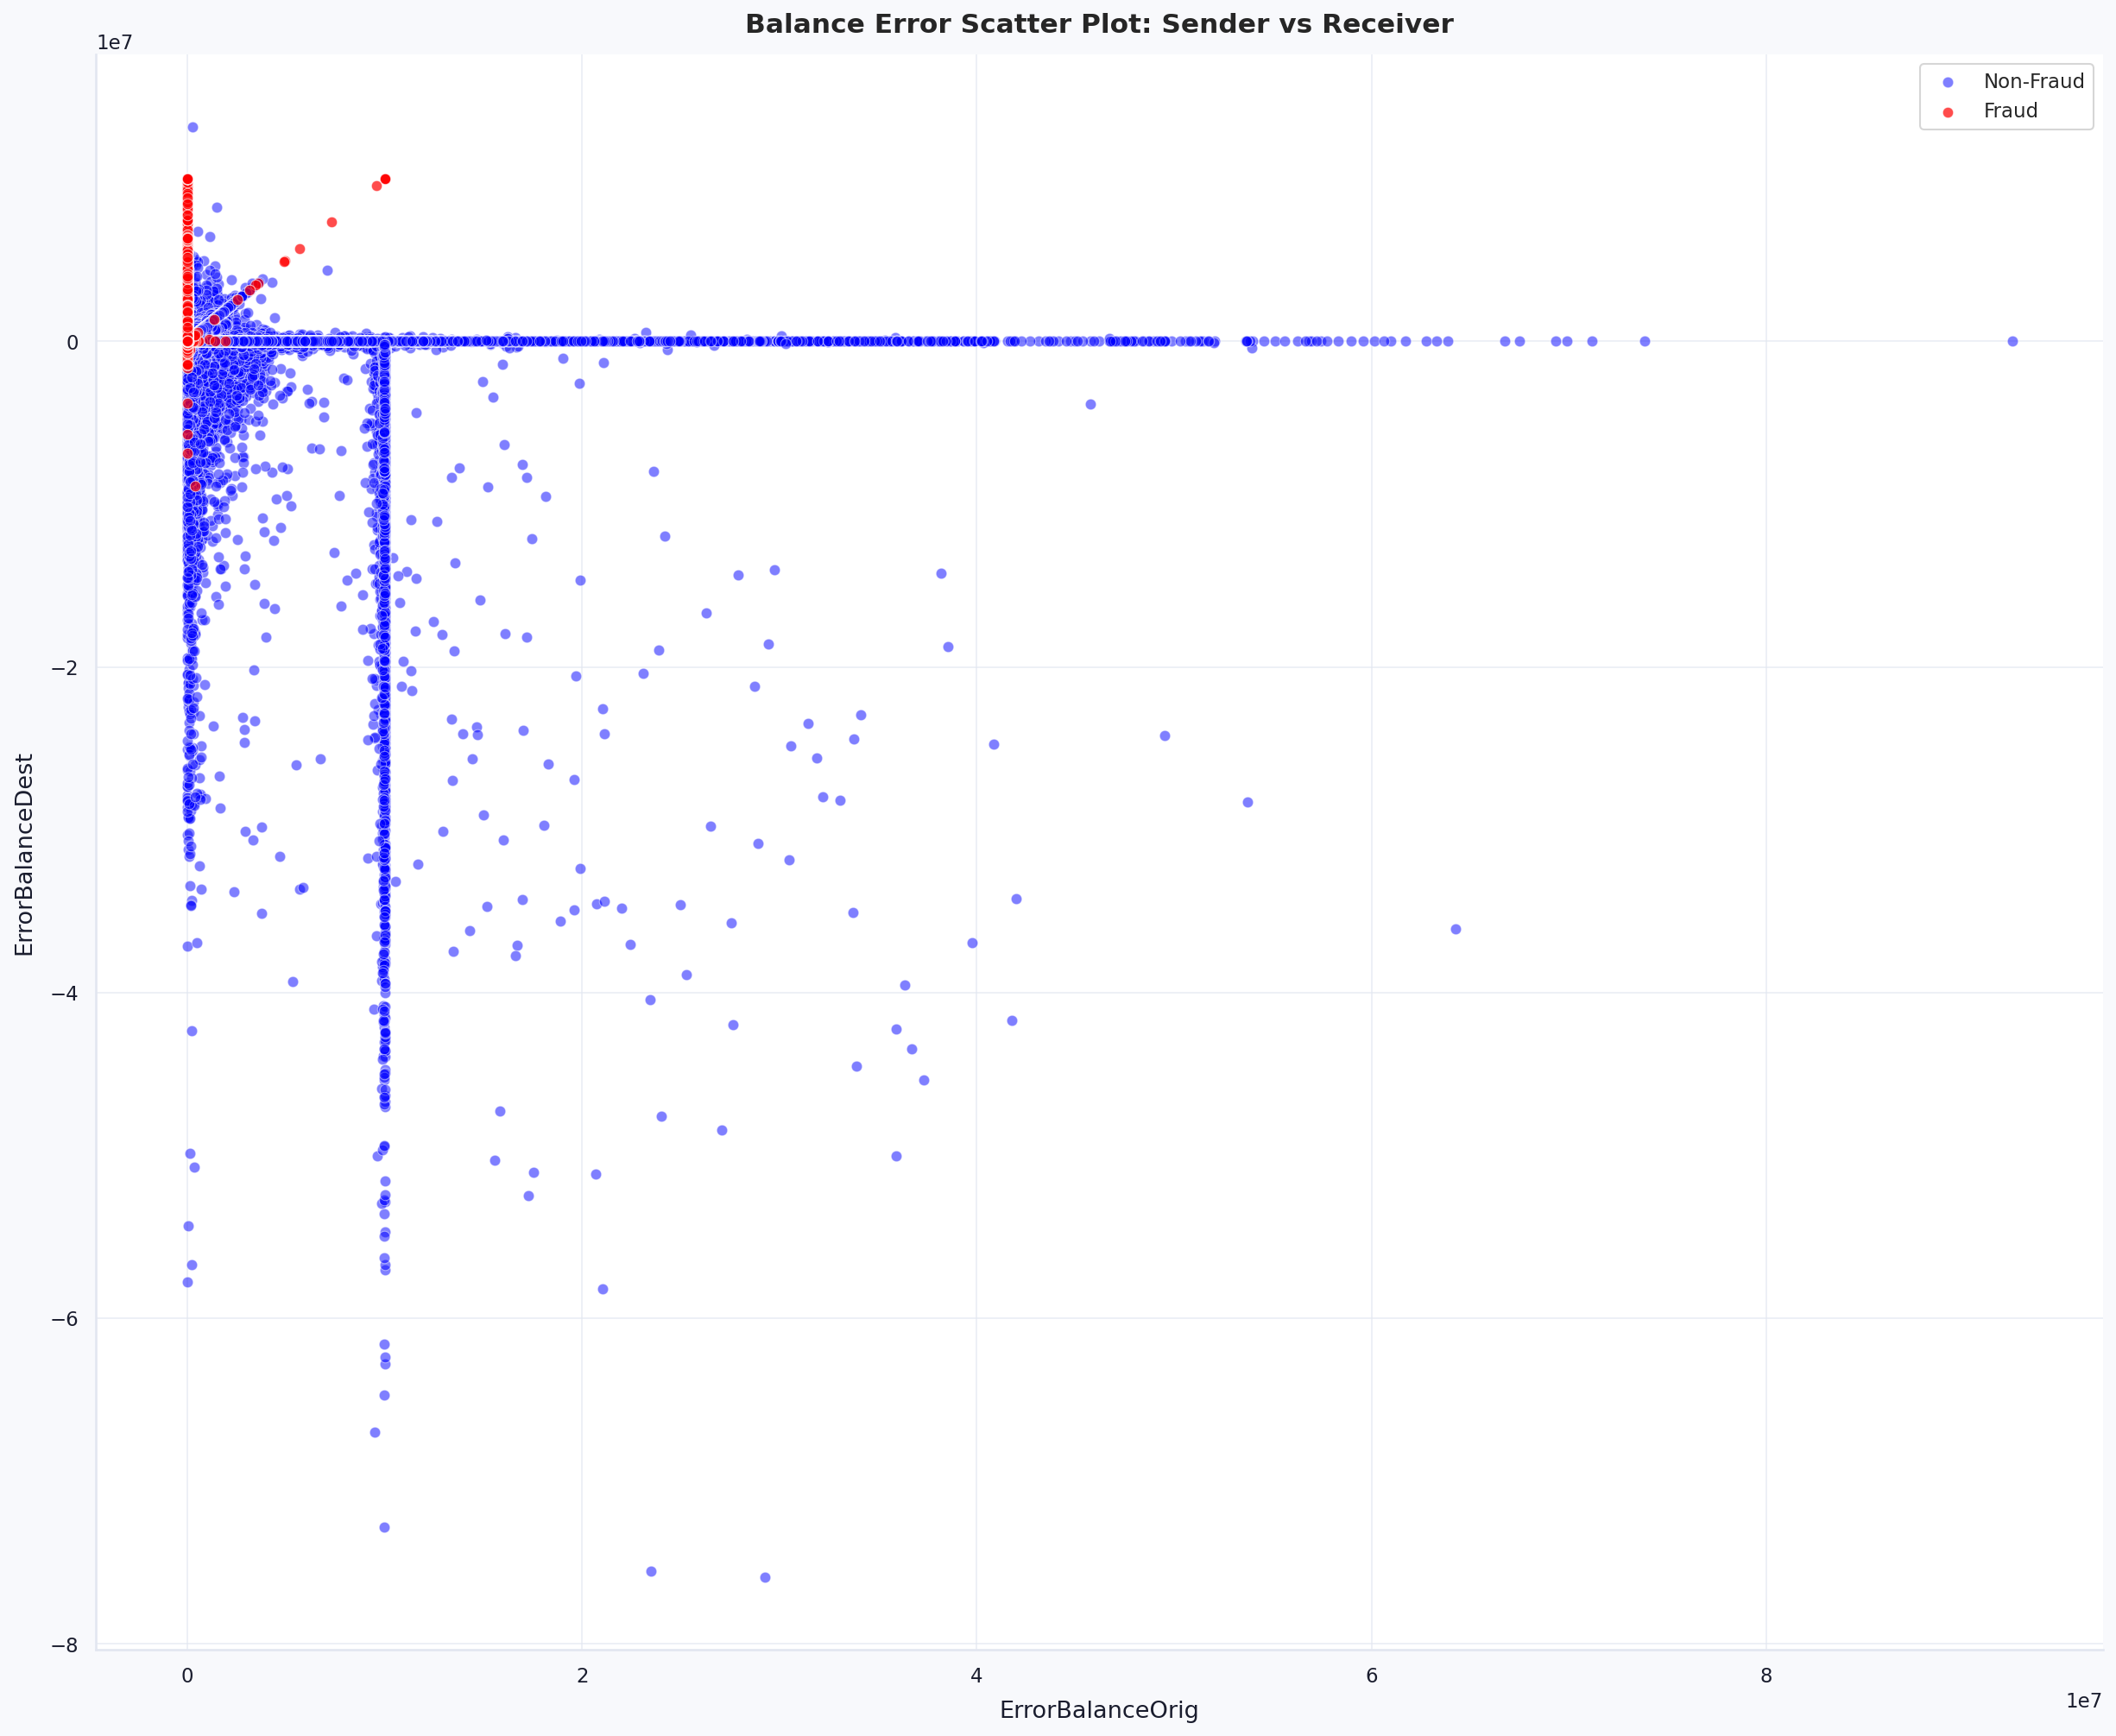

In [ ]:
plt.figure(figsize=(20, 16))

# Draw valid transactions 
sns.scatterplot(data=df[df['isFraud'] == 0], 
                x='errorBalanceOrig', y='errorBalanceDest', 
                color='blue', label='Non-Fraud', alpha=0.5)

# Draw fraund transactions
sns.scatterplot(data=df[df['isFraud'] == 1], 
                x='errorBalanceOrig', y='errorBalanceDest', 
                color='red', label='Fraud', alpha=0.7)

plt.title('Balance Error Scatter Plot: Sender vs Receiver')
plt.xlabel('ErrorBalanceOrig')
plt.ylabel('ErrorBalanceDest')
plt.legend()
plt.show()

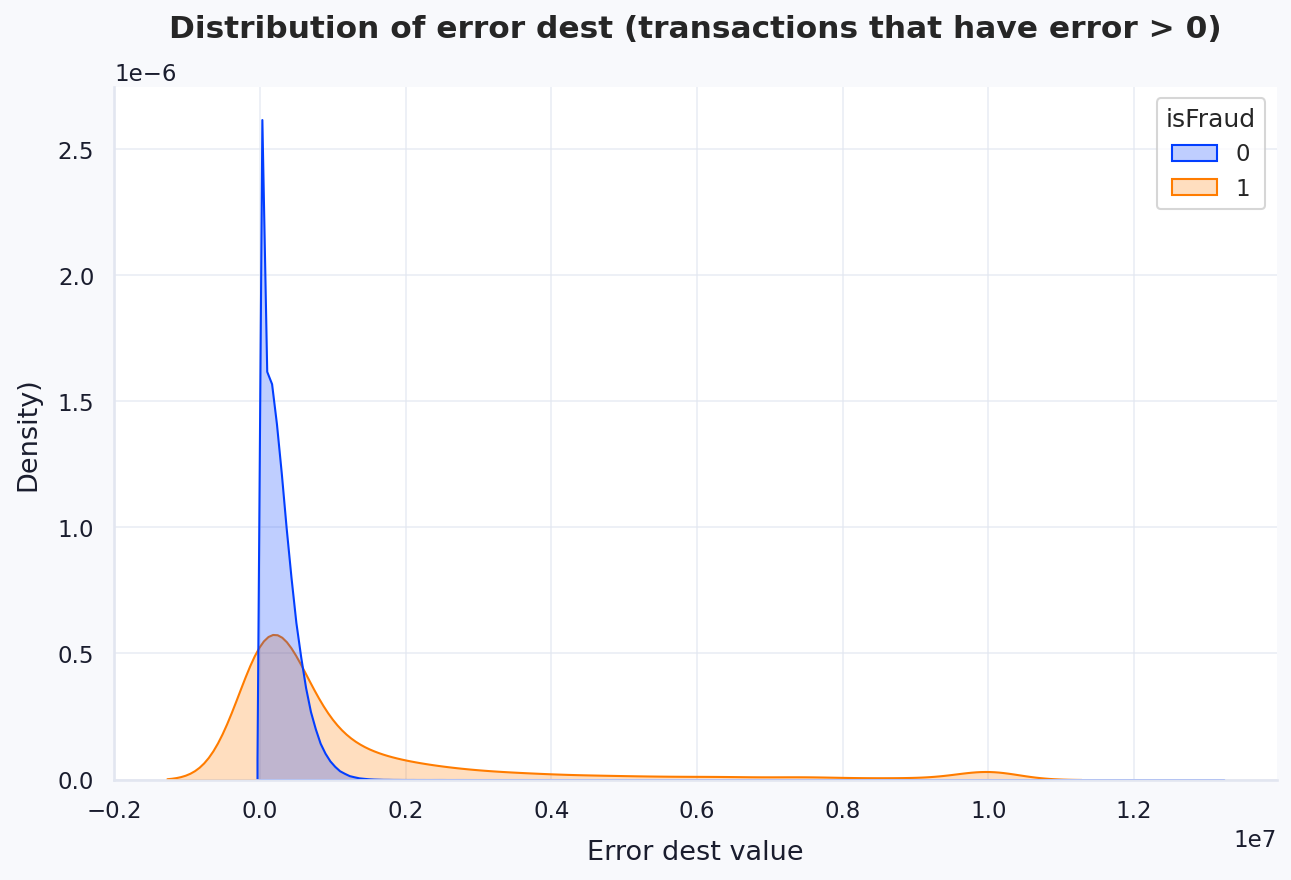

In [49]:
error_dest_df = df[df['errorBalanceDest'] > 0]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=error_dest_df, x='errorBalanceDest', hue='isFraud', 
            common_norm=False, fill=True, palette='bright')

plt.title('Distribution of error dest (transactions that have error > 0)')
plt.xlabel('Error dest value')
plt.ylabel('Density)')
plt.show()

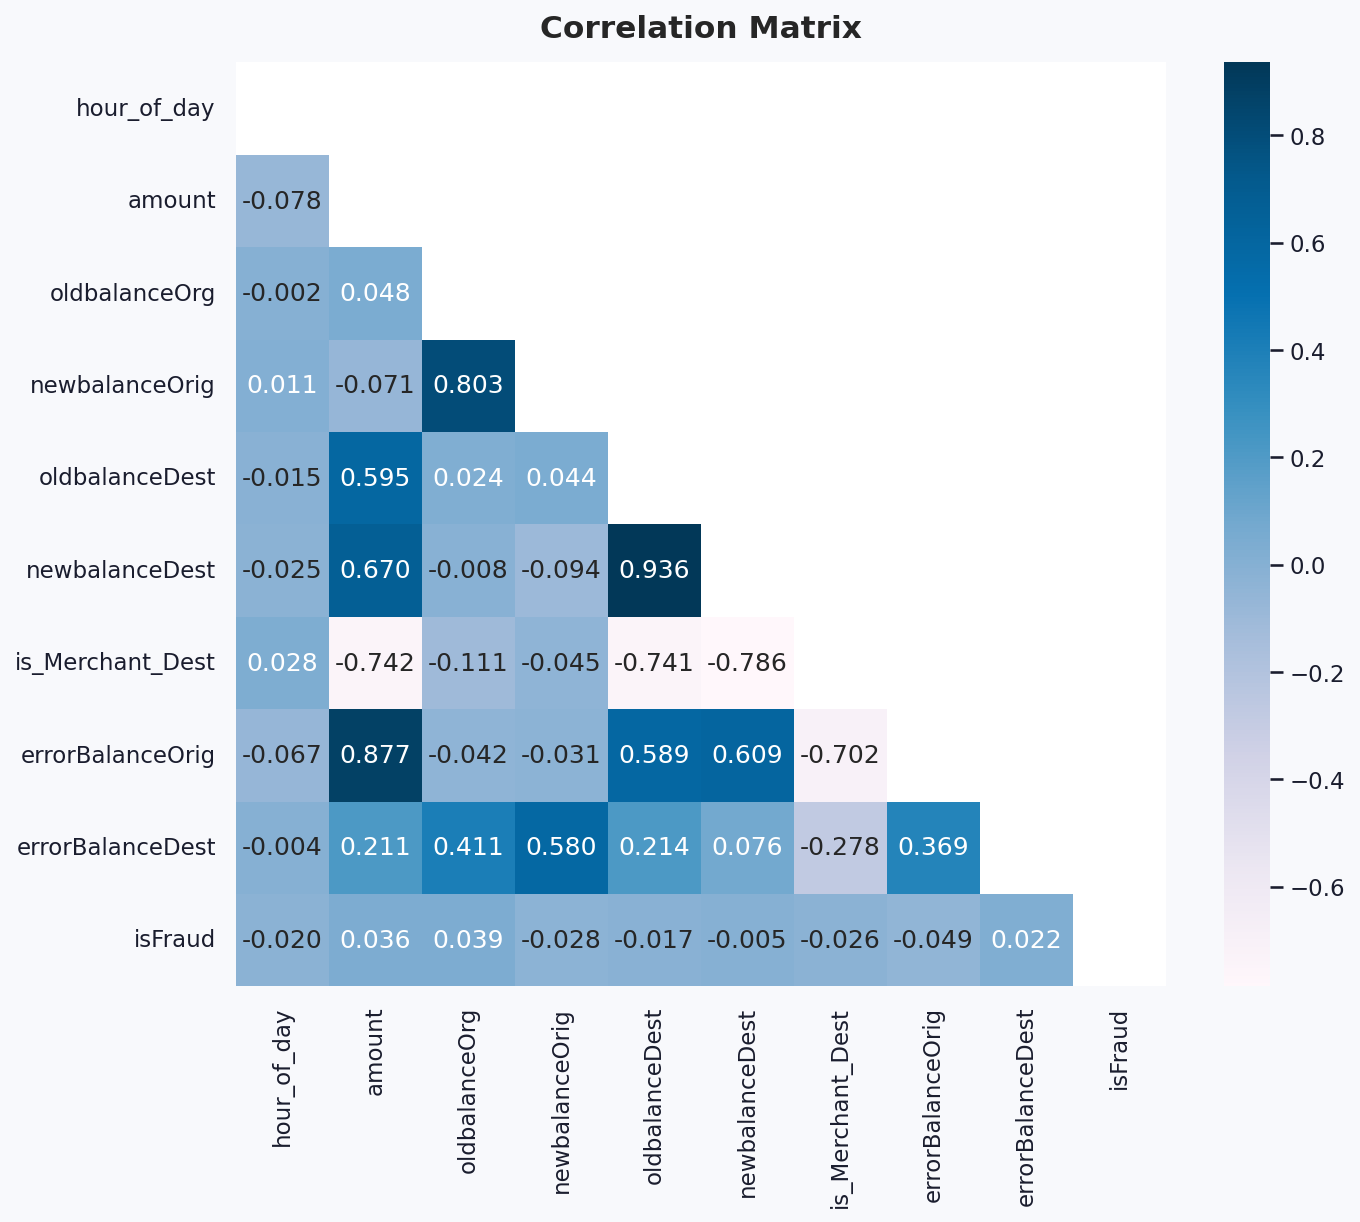

In [50]:
numberic_cols = df.select_dtypes(include= 'number').columns
corr = df[numberic_cols].corr('spearman')
plt.figure(figsize= (10, 8))
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

In [52]:
df.to_csv('onlinefraud_cleaned.csv', index= False)